# §5.4 — Medio estratificado de dos capas (PLIN, haz 2500 μm)

Sistema: capa TOP finita (especie $a$, $\ell^*_{\rm top}$ grande → cono **estrecho**) sobre fondo BOT
semi-infinito (especie $b$, $\ell^*_{\rm bot}$ pequeño → cono **ancho**). Barrido del espesor
$d = m\,\ell^*_{\rm top}$, 5 réplicas, grillas angular y temporal **compartidas** entre espesores.
Base teórica: `desarrollo_teorico_capas.md` (ecuaciones C.1–C.14, predicciones **P1–P7**).

**Protocolo** (mismo esquema que §5.3): Paso 0 convenciones fijadas → Paso 1 carga → Gate →
figuras con predicción explícita → inversión → tabla y números citables.

| Bloque | Predicción que prueba | Ecuación | Archivo |
|---|---|---|---|
| Gate    | **P1**: $m\to0$ ≈ BOT homog., $m\to\infty$ ≈ TOP homog. | — | `gate_limites_capas.pdf` |
| **F13** | **P2** (visual): perfil de **dos escalas** irreducibles | (C.4) | `F13_familia_espesor.pdf` |
| **F14** | **P4**: $\rho(m)$ exponencial, escala $m_\rho=(1-g_{\rm top})/2$; **P5**: colapso abrupto de la FWHM en $m_c$ | (C.9), (C.10) | `F14_observables_vs_d.pdf` |
| **F15** | **P2**: cono único falla / dos conos funciona; **P3**: $w=m/(m+\zeta)$, $\zeta\approx1+\tilde b\approx1.71$, cola pesada | (C.6)–(C.8) | `F15_modelo_dos_conos.pdf` |
| **F16** | **P6a**: $\Delta\theta(t)\propto t^{-1/2}$ en los controles, quiebre hacia arriba a $t^*$ | (C.11) | `F16_ancho_vs_t.pdf` |
| **F17** | **P6b**: $t^*=\alpha\,m^2\tau^*_{\rm top}$, $\alpha\approx3/2$; plateau $R_\infty=\sqrt{\ell^*_{\rm top}/\ell^*_{\rm bot}}$ | (C.12)–(C.14) | `F17_tstar_vs_d2.pdf` |
| **F18** | **P7**: inversión del espesor — $\hat m_w$ (estacionaria, leave-one-out) vs $\hat m_t$ (temporal) vs $m$ real | §C.7 | `F18_inversion_espesor.pdf` |
| Tabla   | $(d, m, {\rm FWHM}, E_0, \rho, w, t^*, \hat m)$ + números citables | — | `tabla_capas.csv/.tex` |

**Narrativa** (contraste con §5.3): la **mezcla** es un medio efectivo exacto donde la superposición
naive falla (brecha de Jensen $\propto x(1-x)$); el medio **estratificado** es lo opuesto — no admite
medio efectivo (perfil de dos escalas) pero la superposición de dos conos sí lo describe, porque las
especies están segregadas espacialmente. El time-resolved añade lo que el estacionario no tiene: la
profundidad de la interfaz vía $t^*\propto d^2$. F18 cierra el círculo: el cono como sonda métrica de $d$.


In [1]:
import sys
import os
sys.path.append(os.path.abspath("../../"))

import pathlib
FIGDIR = pathlib.Path("figs_tesis")
FIGDIR.mkdir(exist_ok=True)


In [2]:
from utils.loaders import load_sweep
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE, COL

import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from scipy import stats
from scipy.optimize import curve_fit


@dataclass
class GroupedZ:
    z: float                    # espesor de TOP [um]
    mult: float                 # m = z / l*_top
    replicas_keys: list = field(default_factory=list)
    name: str = ""


## Paso 0 — Convenciones fijadas de antemano

Idénticas a §5.3 (cualquier asimetría de procesamiento contamina la comparación con los controles):

- **Canal primario:** lineal co-polarizado, corte $\phi=0$.
- **Línea base:** mediana de cola (`tail_baseline`), calculada **por perfil, antes de restar nada**;
  el $q$ auxiliar de la máscara de cola se ancla a $\ell^*_{\rm bot}$ (el cono más ancho fija dónde
  empieza la cola común a todos los espesores).
- **Estimador de perfil:** cociente de **intensidades sumadas** sobre réplicas ($\sum C/\sum I$ por bin)
  para curvas de alto S/N (obligatorio en el time-resolved); observables con barras de error se calculan
  **por réplica** y se reporta $\pm\,{\rm SE}$ o $\pm\,t_{0.975,n-1}\,s/\sqrt{n}$.
- **Ajustes:** ningún error de `curve_fit` por bin (correlación angular del next-event estimator);
  los pesos de los ajustes de saturación son los SE por réplica.
- **Ventanas:** cono completo $\theta \le 6$ mrad (escala BOT); zoom del ápice $\theta \le 1$ mrad
  (escala TOP); gate de calidad temporal: pico $>5\sigma$ del ruido de cola y FWHM finita.
- **Constantes teóricas** (cero parámetros libres, C.6/C.12/C.14): $\tilde b = 0.7104$,
  $\zeta_{\rm teo} = 1+\tilde b$, $\alpha_{\rm teo} = 3/2$, $R_\infty = \sqrt{\ell^*_{\rm top}/\ell^*_{\rm bot}}$.


In [3]:
# ===========================================================================
# Paso 0 -- convenciones del analisis (fijadas antes de tocar datos)
# ===========================================================================
CONV = dict(
    phi_main        = 0,            # corte phi = 0 (X-scan)
    channel_main    = "co",         # lineal co-polarizado
    th_full_mrad    = 6.0,          # ventana del cono completo (escala BOT)
    th_apex_mrad    = 1.0,          # zoom del apice (escala TOP)
    th_fit_rad      = 6.0e-3,       # ventana de ajuste de F15
    q_min_baseline  = 25.0,         # mediana de cola, q anclado a l*_bot
    snr_min_time    = 5.0,          # gate de calidad por bin temporal (sigmas)
    conf            = 0.975,        # dos colas al 95%
)

def t_ci(n, conf=CONV["conf"]):
    return stats.t.ppf(conf, n - 1)

# --- constantes teoricas del desarrollo C.1-C.14 (cero parametros libres) ---
B_MILNE    = 0.7104                 # z0/l*, condicion de Milne
ZETA_TEO   = 1.0 + B_MILNE          # C.7: profundidad caracteristica de w(m)
ALPHA_TEO  = 1.5                    # C.12: t* = alpha m^2 tau*_top

def cone_shape(qq, b=B_MILNE):
    """Cono difusivo AWM normalizado, C(0) = 1."""
    qq = np.maximum(np.asarray(qq, float), 1e-9)
    return (1.0/(1.0 + 2.0*b)) / (1.0 + qq)**2 * (1.0 + (1.0 - np.exp(-2.0*b*qq)) / qq)

def w_ratio(m_, zeta):              # C.7 (1 parametro, cola pesada)
    return m_ / (m_ + zeta)

def w_exp(m_, zeta):                # alternativa exponencial (debe perder, P3b)
    return 1.0 - np.exp(-m_ / zeta)

def w_teo(m_):                      # C.6 (CERO parametros; valida solo m >~ 1)
    m_ = np.asarray(m_, float)
    return np.clip((m_ - 1.0) / (m_ + B_MILNE), 0.0, None)

print(f"zeta_teo = {ZETA_TEO:.3f}   alpha_teo = {ALPHA_TEO:.2f}   t(0.975,4) = {t_ci(5):.3f}")


zeta_teo = 1.710   alpha_teo = 1.50   t(0.975,4) = 2.776


## Paso 1 — Carga, agrupación por espesor y parámetros del sistema

Se leen de `params_flat` de la réplica 0: $\ell^*_{\rm top}$, $\ell^*_{\rm bot}$, y — si el
script de generación los archivó — $\ell_s^{\rm top}$ y/o $g_{\rm top}$ (necesarios para la
predicción **P4**, $m_\rho = (1-g_{\rm top})/2$; si faltan, fijar a mano desde
`derived_quantities` de `luminis_mc`). Los controles de extremo del propio barrido
($m$ mínimo y máximo) sirven de base **medida** para la superposición (C.8) y de
referencias temporales sin interpolación.


In [4]:
# ===========================================================================
# Paso 1 -- carga y agrupacion por espesor
# ===========================================================================
save_path = "/Users/niaggar/Results"
folder = "study_two_layers__PLIN__beam2500"

N_MEDIUM = 1.33
WAVELENGTH = 0.514
k = 2 * np.pi * N_MEDIUM / WAVELENGTH
V_UM_FS = 0.299792458 / N_MEDIUM        # velocidad en el medio [um/fs]
N_TIME_BINS = 100                       # TIME_NBINS del script (bin 0 = integrado)

sweep_data = load_sweep(folder, base_path=Path(save_path))
print(f"Loaded {len(sweep_data.keys())} datasets")

_by_z = {}
for key in sweep_data.keys():
    m = re.search(r"z_interface_([0-9.]+)__rep(\d+)", key)
    if not m:
        print(f"[skip] {key}")
        continue
    _by_z.setdefault(float(m.group(1)), []).append(key)

Z_VALUES = np.array(sorted(_by_z))

# parametros compartidos (replica 0 del primer espesor)
_p0 = sweep_data[sorted(_by_z[Z_VALUES[0]])[0]].params_flat
L_TOP = float(_p0["l_star_top"])
L_BOT = float(_p0["l_star_bot"])
TAU_TOP_FS = L_TOP / V_UM_FS            # tau*_top [fs]
GRID = _p0.get("time_grid", None)

# --- P4 necesita la escala somera de la capa superior: l_s^top o g_top -----
def _first_key(p, names):
    for nm in names:
        if nm in p:
            return float(p[nm])
    return np.nan

LS_TOP = _first_key(_p0, ["l_s_top", "ls_top", "scattering_mfp_top",
                          "scattering_mean_free_path_top"])
G_TOP  = _first_key(_p0, ["g_top", "anisotropy_top", "anisotropy_g_top"])
if np.isnan(LS_TOP) and not np.isnan(G_TOP):
    LS_TOP = (1.0 - G_TOP) * L_TOP
if np.isnan(LS_TOP):
    print("[WARN] ni l_s_top ni g_top en params_flat -> fija LS_TOP a mano "
          "(derived_quantities de luminis_mc para la especie TOP)")
M_RHO_PRED = LS_TOP / (2.0 * L_TOP)     # C.9 en unidades de m

# --- P6 plateau (C.14): contraste asintotico, cero parametros --------------
R_INF_PRED = np.sqrt(L_TOP / L_BOT)

groups = [GroupedZ(z=z, mult=z / L_TOP, replicas_keys=sorted(_by_z[z]),
                   name=rf"$m={z/L_TOP:.1f}$")
          for z in Z_VALUES]

print(f"l*_top = {L_TOP:.2f} um   l*_bot = {L_BOT:.2f} um   "
      f"l_s_top = {LS_TOP:.2f} um   tau*_top = {TAU_TOP_FS:.1f} fs")
print(f"predicciones: m_rho = {M_RHO_PRED:.3f}   R_inf = {R_INF_PRED:.3f}   "
      f"zeta = {ZETA_TEO:.2f}   alpha = {ALPHA_TEO:.2f}")
print("espesores [z um | m | n replicas]:")
for g in groups:
    print(f"  {g.z:8.2f} | {g.mult:5.2f} | {len(g.replicas_keys)}")

# controles de extremo dentro del propio barrido (misma grilla):
G_BOTLIKE = groups[0]      # m minimo  -> ~ BOT homogeneo
G_TOPLIKE = groups[-1]     # m maximo  -> ~ TOP homogeneo


Loaded 50 datasets
[WARN] ni l_s_top ni g_top en params_flat -> fija LS_TOP a mano (derived_quantities de luminis_mc para la especie TOP)
l*_top = 117.94 um   l*_bot = 23.16 um   l_s_top = nan um   tau*_top = 523.2 fs
predicciones: m_rho = nan   R_inf = 2.257   zeta = 1.71   alpha = 1.50
espesores [z um | m | n replicas]:
     11.79 |  0.10 | 5
     23.59 |  0.20 | 5
     58.97 |  0.50 | 5
    117.94 |  1.00 | 5
    176.91 |  1.50 | 5
    235.88 |  2.00 | 5
    353.82 |  3.00 | 5
    589.70 |  5.00 | 5
    825.58 |  7.00 | 5
   1179.40 | 10.00 | 5


## Paso 2 — Utilidades de reducción

Mismo pipeline que §5.1/§5.3: stitching de las dos ventanas angulares con chequeo de solape,
mediana de cola por perfil, perfiles de alto S/N por suma de intensidades y observables por réplica.


In [5]:
# ===========================================================================
# Paso 2 -- stitching, baseline, perfiles y observables
# ===========================================================================
eps = 1e-30

def load_stitched(k_, lstar, th1, g1, th2, g2, key, warn=0.05):
    theta_1 = th1[-1]
    lo = 0.9 * theta_1
    ov = (th2 >= lo) & (th2 <= theta_1)
    if ov.any():
        g1_on2 = np.interp(th2[ov], th1, g1)
        resid = np.abs(g2[ov] - g1_on2)
        if np.max(resid) > warn:
            print(f"[stitch WARN] {key}: max solape {np.max(resid):.3f}")
    keep2 = th2 > theta_1
    theta = np.concatenate([th1, th2[keep2]])
    g = np.concatenate([g1, g2[keep2]])
    return theta, k_ * lstar * theta, g


def tail_baseline(q, y, q_min=CONV["q_min_baseline"], n_min=5, frac=0.85):
    q = np.asarray(q); y = np.asarray(y)
    m = q > q_min
    if np.count_nonzero(m) >= n_min:
        return np.median(y[m])
    q_cut = frac * np.nanmax(q)
    m = q >= q_cut
    if np.count_nonzero(m) < n_min:
        idx = np.argsort(q)[-n_min:]
        return np.median(y[idx])
    return np.median(y[m])


def _profiles_raw(key, phi_index, channel, time_index):
    sw = sweep_data[key]
    p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=linear,
                      time_index=time_index, reduce=phi_cut(phi_index))
    p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=linear,
                      time_index=time_index, reduce=phi_cut(phi_index))
    return p1, p2


def intensity_sum(keys, phi_index, channel, time_index=0):
    """Suma C y B sobre replicas (mismo N_PHOTONS -> suma == promedio)."""
    Isum1 = Isum2 = Bsum1 = Bsum2 = None
    th1 = th2 = None
    for key in keys:
        p1, p2 = _profiles_raw(key, phi_index, channel, time_index)
        c1 = np.asarray(p1.coherent[channel], float)
        c2 = np.asarray(p2.coherent[channel], float)
        b1 = np.asarray(p1.incoherent[channel], float)
        b2 = np.asarray(p2.incoherent[channel], float)
        if Isum1 is None:
            Isum1, Isum2 = np.zeros_like(c1), np.zeros_like(c2)
            Bsum1, Bsum2 = np.zeros_like(b1), np.zeros_like(b2)
            th1, th2 = np.asarray(p1.theta), np.asarray(p2.theta)
        Isum1 += c1; Isum2 += c2; Bsum1 += b1; Bsum2 += b2
    keep2 = th2 > th1[-1]
    theta = np.concatenate([th1, th2[keep2]])
    I = np.concatenate([Isum1, Isum2[keep2]])
    B = np.concatenate([Bsum1, Bsum2[keep2]])
    return theta, I, B


def profile_mean(grouped, phi_index=CONV["phi_main"], channel=CONV["channel_main"],
                 time_index=0):
    """Realce de alto S/N: cociente de intensidades sumadas; baseline -> 1.
    q auxiliar anclado a l*_bot (solo para la mascara de cola)."""
    theta, I, B = intensity_sum(grouped.replicas_keys, phi_index, channel, time_index)
    E = (I + eps) / (B + eps)
    q_anchor = k * L_BOT * theta
    return theta, E - tail_baseline(q_anchor, E) + 1.0


def profile_one(key, phi_index=CONV["phi_main"], channel=CONV["channel_main"],
                time_index=0):
    """Realce de UNA replica (para barras de error de observables)."""
    p1, p2 = _profiles_raw(key, phi_index, channel, time_index)
    E1 = (np.asarray(p1.coherent[channel]) + eps) / (np.asarray(p1.incoherent[channel]) + eps)
    E2 = (np.asarray(p2.coherent[channel]) + eps) / (np.asarray(p2.incoherent[channel]) + eps)
    theta, q_anchor, E = load_stitched(k, L_BOT, np.asarray(p1.theta), E1,
                                       np.asarray(p2.theta), E2, key)
    return theta, E - tail_baseline(q_anchor, E) + 1.0


# --- observables sobre (theta, E) ------------------------------------------
def peak_height(E, n=3):
    return float(np.median(E[:n]))


def fwhm_theta(theta, E, n=3, baseline=1.0):
    """FWHM [rad] por primer cruce a media altura (interp. lineal)."""
    E0 = peak_height(E, n)
    half = baseline + 0.5 * (E0 - baseline)
    below = np.where(E < half)[0]
    if len(below) == 0 or below[0] == 0:
        return np.nan
    i = int(below[0])
    th_half = theta[i-1] + (half - E[i-1]) * (theta[i] - theta[i-1]) / (E[i] - E[i-1])
    return 2.0 * th_half


def estimate_noise(E, n_tail=150):
    tail = np.asarray(E[-n_tail:], float)
    kern = np.ones(15) / 15.0
    smooth = np.convolve(tail, kern, mode="same")
    return float(np.std(tail[10:-10] - smooth[10:-10]))


def metric_over_replicas(grouped, phi_index=CONV["phi_main"],
                         channel=CONV["channel_main"], time_index=0):
    """(E0, sE0, FWHM[mrad], sFWHM) con error estandar sobre replicas."""
    E0s, fws = [], []
    for key in grouped.replicas_keys:
        theta, E = profile_one(key, phi_index, channel, time_index)
        E0s.append(peak_height(E))
        fws.append(fwhm_theta(theta, E) * 1e3)
    E0s, fws, n = np.asarray(E0s), np.asarray(fws), len(E0s)
    return (E0s.mean(), E0s.std(ddof=1) / np.sqrt(n),
            np.nanmean(fws), np.nanstd(fws, ddof=1) / np.sqrt(n))


# --- centros de los bins temporales ----------------------------------------
def time_centers_fs(grid, n_bins):
    """Centros (n) o bordes (n+1) del grid archivado; si no hay, reconstruye
    bordes geometricos dt..t_max (WARN)."""
    if isinstance(grid, dict):
        arrays = {}
        for kk, vv in grid.items():
            try:
                a = np.asarray(vv, float)
            except Exception:
                continue
            if a.ndim == 1 and len(a) in (n_bins, n_bins + 1):
                arrays[kk] = a
        for kk, a in arrays.items():
            if len(a) == n_bins + 1:
                print(f"[time grid] usando bordes '{kk}'")
                return np.sqrt(a[:-1] * a[1:])
        for kk, a in arrays.items():
            print(f"[time grid] usando centros '{kk}'")
            return a
    dt = float(grid["dt_fs"]) if isinstance(grid, dict) and "dt_fs" in grid else 1.0
    tmax = float(grid["t_max_fs"]) if isinstance(grid, dict) and "t_max_fs" in grid else n_bins
    print("[time grid WARN] sin arrays en params: reconstruyendo bordes "
          "geometricos dt..t_max -- verifica contra utils.time.build_time_grid")
    edges = np.geomspace(dt, tmax, n_bins + 1)
    return np.sqrt(edges[:-1] * edges[1:])

T_FS = time_centers_fs(GRID, N_TIME_BINS)
print(f"bins temporales: {len(T_FS)}   t in [{T_FS[0]:.1f}, {T_FS[-1]:.0f}] fs "
      f"= [{T_FS[0]/TAU_TOP_FS:.3f}, {T_FS[-1]/TAU_TOP_FS:.1f}] tau*_top")


[time grid WARN] sin arrays en params: reconstruyendo bordes geometricos dt..t_max -- verifica contra utils.time.build_time_grid
bins temporales: 100   t in [1.0, 98] fs = [0.002, 0.2] tau*_top


## Gate de límites — **P1**

Antes de cualquier física: los extremos del barrido deben degenerar en los medios homogéneos de §5.1.

- $m$ mínimo (TOP casi transparente) ≈ **BOT homogéneo**.
- $m$ máximo (interfaz fuera del alcance difusivo del barrido temporal) ≈ **TOP homogéneo**.

Las grillas de §5.1 difieren (ancla propia por radio) → se interpola la referencia sobre la grilla
del barrido. Se reporta $\chi^2$/bin y RMS en la ventana del cono de cada control. Si el gate falla,
nada de lo que sigue es interpretable: los controles son la base medida de (C.8).


[gate m=0.1 vs radius_0.075] chi2/bin = 9798.53   RMS = 2.64e-01   (theta <= 8.0 mrad, n=5)
[gate m=10.0 vs radius_0.035] chi2/bin = 46.66   RMS = 2.48e-02   (theta <= 2.0 mrad, n=5)


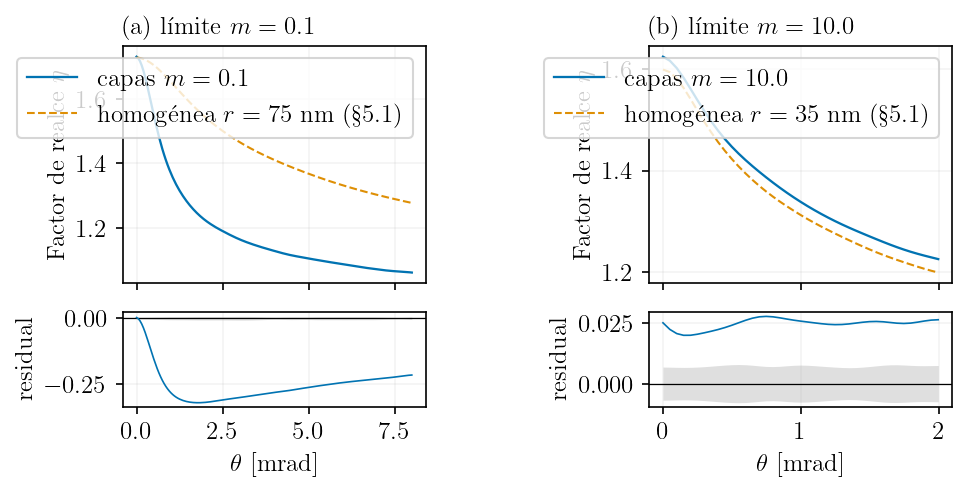

In [6]:
# ===========================================================================
# GATE (P1): m_min vs homogenea BOT;  m_max vs homogenea TOP
# ===========================================================================
HOMOG_51 = "study_homog_timeresolved__PLIN__beam2500"
GATES = [(G_BOTLIKE, "radius_0.075", "homogénea $r=75$ nm (§5.1)"),
         (G_TOPLIKE, "radius_0.035", "homogénea $r=35$ nm (§5.1)")]
GATE_THETA_MAX = [8.0, 2.0]      # mrad: cono ancho / cono estrecho
GATE_STATS = {}

try:
    sweep_h = load_sweep(HOMOG_51, base_path=Path(save_path))
    _have_51 = True
except Exception as err:
    print(f"[gate] §5.1 no disponible: {err}")
    _have_51 = False

if _have_51:
    apply(width_frac=1.0)
    fig, axes = plt.subplots(2, 2, figsize=(TEXTWIDTH_IN, 0.5 * TEXTWIDTH_IN), sharex="col",
                             gridspec_kw={"height_ratios": [3, 1.2],
                                          "hspace": 0.08, "wspace": 0.25})
    for col, ((g_mix, sub, lab), thmax) in enumerate(zip(GATES, GATE_THETA_MAX)):
        keys_h = sorted(k_ for k_ in sweep_h.keys() if sub in k_)
        if not keys_h:
            print(f"[gate] no encontré '{sub}' en {HOMOG_51}")
            continue

        # medias por replica para sigma (barrido de capas)
        curves_m = [profile_one(key)[1] for key in g_mix.replicas_keys]
        th_m = profile_one(g_mix.replicas_keys[0])[0]
        Em = np.vstack(curves_m).mean(0)
        Sm = np.vstack(curves_m).std(0, ddof=1)

        # referencia homogenea (su propio sweep, su propia grilla)
        curves_h, th_h = [], None
        for key in keys_h:
            sw = sweep_h[key]
            p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=linear,
                              time_index=0, reduce=phi_cut(CONV["phi_main"]))
            p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=linear,
                              time_index=0, reduce=phi_cut(CONV["phi_main"]))
            ch = CONV["channel_main"]
            E1 = (np.asarray(p1.coherent[ch]) + eps) / (np.asarray(p1.incoherent[ch]) + eps)
            E2 = (np.asarray(p2.coherent[ch]) + eps) / (np.asarray(p2.incoherent[ch]) + eps)
            th_h, q_h, Eh = load_stitched(k, L_BOT, np.asarray(p1.theta), E1,
                                          np.asarray(p2.theta), E2, key)
            curves_h.append(Eh - tail_baseline(q_h, Eh) + 1.0)
        Eh = np.vstack(curves_h).mean(0)
        Sh = np.vstack(curves_h).std(0, ddof=1)

        Eh_i = np.interp(th_m, th_h, Eh)
        Sh_i = np.interp(th_m, th_h, Sh)
        n = len(g_mix.replicas_keys)
        sig = np.sqrt(Sm ** 2 + Sh_i ** 2) / np.sqrt(n)
        res = Em - Eh_i

        thm = th_m * 1e3
        msk = thm <= thmax
        chi2 = np.mean((res[msk] / np.where(sig[msk] > 0, sig[msk], np.inf)) ** 2)
        rms = np.sqrt(np.mean(res[msk] ** 2))
        GATE_STATS[sub] = (chi2, rms)

        ax1, ax2 = axes[0, col], axes[1, col]
        ax1.plot(thm[msk], Em[msk], color=COL[0], lw=1.1,
                 label=rf"capas $m={g_mix.mult:.1f}$")
        ax1.plot(thm[msk], Eh_i[msk], "--", color=COL[1], lw=1.0, label=lab)
        ax1.set_ylabel(r"Factor de realce $\eta$")
        ax1.grid(alpha=0.15); ax1.legend()
        ax1.set_title(rf"({chr(97+col)}) límite $m={g_mix.mult:.1f}$", loc="left")

        ax2.axhline(0, c="k", lw=0.6)
        ax2.fill_between(thm[msk], -2 * sig[msk], 2 * sig[msk], color="gray",
                         alpha=0.25, lw=0)
        ax2.plot(thm[msk], res[msk], lw=0.8, color=COL[0])
        ax2.set_xlabel(r"$\theta$ [mrad]"); ax2.set_ylabel("residual")
        ax2.grid(alpha=0.15)

        print(f"[gate m={g_mix.mult:.1f} vs {sub}] chi2/bin = {chi2:.2f}   "
              f"RMS = {rms:.2e}   (theta <= {thmax} mrad, n={n})")
    fig.savefig(FIGDIR / "gate_limites_capas.pdf")
    plt.show()


## F13 — Familia estacionaria: el perfil de dos escalas — **P2** (visual)

Con $\ell^*_{\rm bot} \ll \ell^*_{\rm top}$ el perfil **no** es un cono de ancho intermedio
(eso sería un medio efectivo): es un cono ancho (fondo, escala $1/k\ell^*_{\rm bot}$) sobre el
que emerge una espiga estrecha (top, escala $1/k\ell^*_{\rm top}$) cuyo peso crece con $d$
según (C.7). Panel (a): cono completo; panel (b): zoom del ápice donde vive la espiga.
La cuantificación de P2 (RMS de cono único vs dos conos) se hace en F15.


/var/folders/hl/qm9fczw178qg19fkz2_x7sqr0000gn/T/ipykernel_64822/2003817691.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


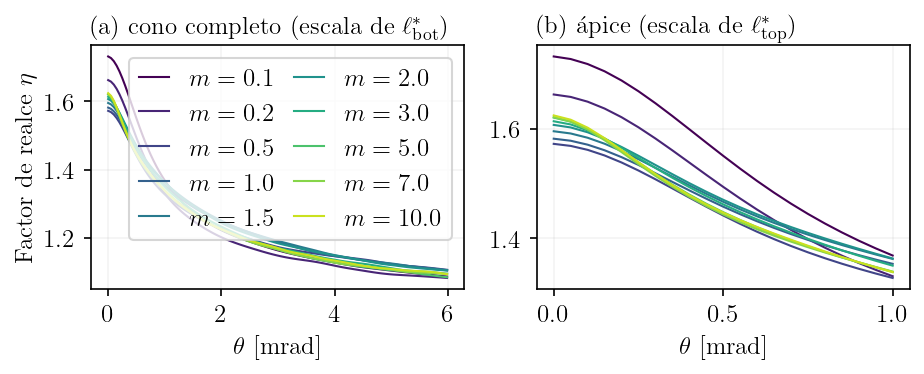

In [7]:
# ===========================================================================
# F13 -- familia eta(theta; d), realce de intensidades sumadas
# ===========================================================================
apply(width_frac=1.0)
cmap = plt.cm.viridis(np.linspace(0.0, 0.92, len(groups)))
TH_A = CONV["th_full_mrad"]
TH_B = CONV["th_apex_mrad"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN))
for c, g in zip(cmap, groups):
    theta, E = profile_mean(g)
    thm = theta * 1e3
    for ax, tmax in ((ax1, TH_A), (ax2, TH_B)):
        msk = thm <= tmax
        ax.plot(thm[msk], E[msk], color=c, lw=1.0,
                label=rf"$m={g.mult:.1f}$" if ax is ax1 else None)
ax1.set_xlabel(r"$\theta$ [mrad]"); ax1.set_ylabel(r"Factor de realce $\eta$")
ax1.grid(alpha=0.15); ax1.legend(ncol=2, columnspacing=0.8, handlelength=1.2)
ax1.set_title(r"(a) cono completo (escala de $\ell^*_{\rm bot}$)", loc="left")
ax2.set_xlabel(r"$\theta$ [mrad]")
ax2.grid(alpha=0.15)
ax2.set_title(r"(b) ápice (escala de $\ell^*_{\rm top}$)", loc="left")
fig.tight_layout()
fig.savefig(FIGDIR / "F13_familia_espesor.pdf")
plt.show()


## F14 — Observables vs espesor — **P4** y **P5**

Tres observables del mismo cono con **profundidades de sondeo distintas** (§C.5):

- **P4** — $\rho(m) = 2 - E(0)$: la dilución por dispersión simple es un observable de **primer
  evento** [Eq. C.9]: saturación **exponencial** con escala $m_\rho = \ell_s^{\rm top}/(2\ell^*_{\rm top})
  = (1-g_{\rm top})/2$, mucho más somera que la de $w$. El ajuste tiene 3 parámetros
  $(\rho_\infty, \Delta\rho, m_\rho)$ y el $m_\rho$ ajustado se confronta con la predicción.
- **P5** — $\theta_{\rm FWHM}(m)$: colapso **abrupto** de la escala BOT a la TOP cuando la espiga
  supera la media altura, en $m_c$ dado por $w(m_c) = A_{\rm bot}/(A_{\rm top}+A_{\rm bot})$
  [Eq. C.10] (la predicción numérica de $m_c$ se evalúa tras F15, cuando $\zeta$ está medido;
  aquí se localiza el salto observado).


[P4] m_rho ajustado = 0.112 ± 0.004   predicho = nan   chi2/ndf = 826.5/7


/var/folders/hl/qm9fczw178qg19fkz2_x7sqr0000gn/T/ipykernel_64822/4006377802.py:74: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


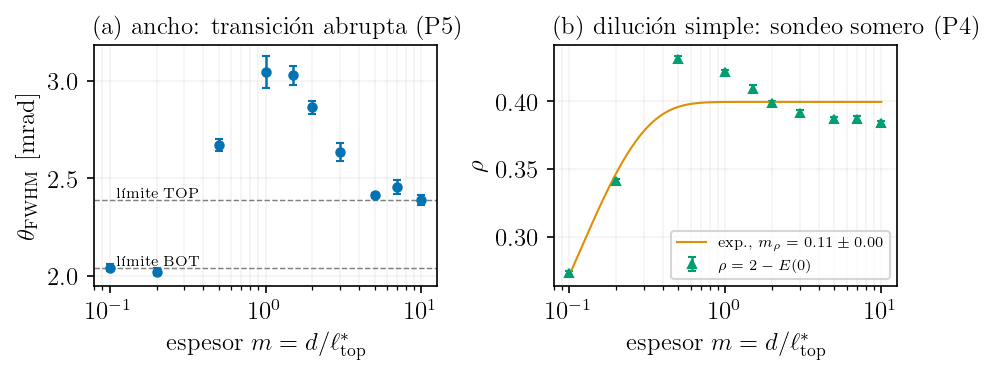

m= 0.10  z=    11.8 um   FWHM= 2.040 mrad   E0=1.7269   rho=0.2731
m= 0.20  z=    23.6 um   FWHM= 2.020 mrad   E0=1.6586   rho=0.3414
m= 0.50  z=    59.0 um   FWHM= 2.671 mrad   E0=1.5689   rho=0.4311
m= 1.00  z=   117.9 um   FWHM= 3.044 mrad   E0=1.5784   rho=0.4216
m= 1.50  z=   176.9 um   FWHM= 3.027 mrad   E0=1.5909   rho=0.4091
m= 2.00  z=   235.9 um   FWHM= 2.863 mrad   E0=1.6014   rho=0.3986
m= 3.00  z=   353.8 um   FWHM= 2.634 mrad   E0=1.6084   rho=0.3916
m= 5.00  z=   589.7 um   FWHM= 2.412 mrad   E0=1.6133   rho=0.3867
m= 7.00  z=   825.6 um   FWHM= 2.453 mrad   E0=1.6133   rho=0.3867
m=10.00  z=  1179.4 um   FWHM= 2.387 mrad   E0=1.6162   rho=0.3838


In [8]:
# ===========================================================================
# F14 -- FWHM(m), E0(m), rho(m) + ajuste exponencial de rho (P4)
# ===========================================================================
mults = np.array([g.mult for g in groups])
met = np.array([metric_over_replicas(g) for g in groups])   # E0,sE0,fw,sfw
E0, sE0, FW, sFW = met.T
RHO, sRHO = 2.0 - E0, sE0

# --- P4: rho(m) = rho_inf + drho * exp(-m/m_rho) ---------------------------
def rho_model(m_, rho_inf, drho, m_rho):
    return rho_inf + drho * np.exp(-m_ / m_rho)

p0_rho = [RHO[-1], RHO[0] - RHO[-1], max(M_RHO_PRED, 0.2) if np.isfinite(M_RHO_PRED) else 0.5]
try:
    popt_r, pcov_r = curve_fit(rho_model, mults, RHO, p0=p0_rho,
                               sigma=np.maximum(sRHO, 1e-4), absolute_sigma=True,
                               maxfev=20000)
    perr_r = np.sqrt(np.diag(pcov_r))
    M_RHO_FIT, sM_RHO_FIT = popt_r[2], perr_r[2]
    chi2_rho = np.sum(((RHO - rho_model(mults, *popt_r)) / np.maximum(sRHO, 1e-4))**2)
    ndf_rho = len(mults) - 3
    print(f"[P4] m_rho ajustado = {M_RHO_FIT:.3f} ± {sM_RHO_FIT:.3f}   "
          f"predicho = {M_RHO_PRED:.3f}   chi2/ndf = {chi2_rho:.1f}/{ndf_rho}")
    _rho_ok = True
except Exception as err:
    print(f"[P4] ajuste de rho fallo: {err}")
    _rho_ok = False

# --- P5: localizar el salto observado de la FWHM ---------------------------
mid_fw = 0.5 * (FW[0] + FW[-1])
below = np.where(FW < mid_fw)[0]
M_C_OBS = np.nan
if len(below) and below[0] > 0:
    i = below[0]
    # interpolacion log-m entre los dos puntos que encierran el cruce
    lm = np.interp(mid_fw, [FW[i], FW[i-1]], np.log([mults[i], mults[i-1]]))
    M_C_OBS = float(np.exp(lm))
    print(f"[P5] salto de FWHM observado entre m={mults[i-1]:g} y m={mults[i]:g} "
          f"-> m_c(obs) ~ {M_C_OBS:.2f}")

apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN))

ax1.errorbar(mults, FW, sFW, fmt="o", ms=4, capsize=2, color=COL[0], ls="none")
ax1.axhline(FW[0], ls="--", c="gray", lw=0.7)
ax1.axhline(FW[-1], ls="--", c="gray", lw=0.7)
ax1.text(mults.min()*1.1, FW[0], r"límite BOT", fontsize=7, va="bottom")
ax1.text(mults.min()*1.1, FW[-1], r"límite TOP", fontsize=7, va="bottom")
if np.isfinite(M_C_OBS):
    ax1.axvline(M_C_OBS, color=COL[2], lw=0.8, ls=":",
                label=rf"$m_c^{{\rm obs}}\approx{M_C_OBS:.1f}$")
    ax1.legend()
ax1.set_xscale("log")
ax1.set_xlabel(r"espesor $m = d/\ell^*_{\rm top}$")
ax1.set_ylabel(r"$\theta_{\rm FWHM}$ [mrad]")
ax1.grid(alpha=0.15, which="both")
ax1.set_title("(a) ancho: transición abrupta (P5)", loc="left")

ax2.errorbar(mults, RHO, sRHO, fmt="^", ms=4, capsize=2, color=COL[2], ls="none",
             label=r"$\rho = 2-E(0)$")
if _rho_ok:
    mm = np.geomspace(mults.min(), mults.max(), 300)
    ax2.plot(mm, rho_model(mm, *popt_r), "-", color=COL[1], lw=1.0,
             label=rf"exp., $m_\rho={M_RHO_FIT:.2f}\pm{sM_RHO_FIT:.2f}$")
    if np.isfinite(M_RHO_PRED):
        ax2.axvline(M_RHO_PRED, color="k", lw=0.7, ls=":",
                    label=rf"$m_\rho^{{\rm teo}}=(1-g_{{\rm top}})/2={M_RHO_PRED:.2f}$")
ax2.set_xscale("log")
ax2.set_xlabel(r"espesor $m = d/\ell^*_{\rm top}$")
ax2.set_ylabel(r"$\rho$")
ax2.grid(alpha=0.15, which="both"); ax2.legend(fontsize=7)
ax2.set_title("(b) dilución simple: sondeo somero (P4)", loc="left")

fig.tight_layout()
fig.savefig(FIGDIR / "F14_observables_vs_d.pdf")
plt.show()

for g, e0, fw, rho in zip(groups, E0, FW, RHO):
    print(f"m={g.mult:5.2f}  z={g.z:8.1f} um   FWHM={fw:6.3f} mrad   "
          f"E0={e0:.4f}   rho={rho:.4f}")


## F15 — Cono único vs superposición de dos conos — **P2** y **P3**

Dos modelos confrontados con cada perfil, en la misma ventana de ajuste:

1. **Cono único** (medio efectivo, 2 parámetros $A, L_{\rm eff}$):
   $\eta_d = 1 + A\,\mathcal C(k L_{\rm eff}\theta)$ — debe fallar en el rango intermedio,
   porque el perfil tiene dos escalas irreducibles (**P2**).
2. **Superposición de dos conos** con los perfiles **medidos** de los controles [Eq. C.8]:
   $\eta_d - 1 = w\,[\gamma_{\rm top}-1] + (1-w)\,[\gamma_{\rm bot}-1]$, un solo parámetro $w$
   por espesor (regresión lineal cerrada). Aquí **sí** debe funcionar: el medio está segregado.
   El residual que quede mide los caminos híbridos (§C.4).

**P3**: $w(m)$ sigue la ley de excursión browniana (C.5)–(C.7): saturación de **cola pesada**
$w = m/(m+\zeta)$ con $\zeta \approx 1+\tilde b = 1.71$; la alternativa exponencial debe perder.
Se superpone además la forma de **cero parámetros** $w_{\rm teo} = (m-1)/(m+\tilde b)$, válida
para $m \gtrsim 1$.


m= 0.10: cono único L_eff=  18.15 um RMS=2.10e-02   |   dos conos w=0.000±0.012 RMS=0.00e+00
m= 0.20: cono único L_eff=  17.94 um RMS=1.98e-02   |   dos conos w=0.564±0.019 RMS=1.60e-02
m= 0.50: cono único L_eff=  11.98 um RMS=1.99e-02   |   dos conos w=1.199±0.018 RMS=1.04e-02
m= 1.00: cono único L_eff=  11.72 um RMS=1.28e-02   |   dos conos w=1.052±0.026 RMS=1.71e-02
m= 1.50: cono único L_eff=  11.84 um RMS=1.27e-02   |   dos conos w=0.952±0.029 RMS=1.98e-02
m= 2.00: cono único L_eff=  12.42 um RMS=1.37e-02   |   dos conos w=0.892±0.015 RMS=1.65e-02
m= 3.00: cono único L_eff=  13.56 um RMS=1.38e-02   |   dos conos w=0.922±0.020 RMS=6.24e-03
m= 5.00: cono único L_eff=  14.23 um RMS=1.39e-02   |   dos conos w=0.995±0.026 RMS=4.25e-03
m= 7.00: cono único L_eff=  14.03 um RMS=1.48e-02   |   dos conos w=1.019±0.022 RMS=3.53e-03
m=10.00: cono único L_eff=  13.81 um RMS=1.64e-02   |   dos conos w=1.000±0.015 RMS=0.00e+00

[P3] cola pesada : zeta = 0.22 ± 0.01  (teo 1.71)   chi2/ndf = 1542.6

/var/folders/hl/qm9fczw178qg19fkz2_x7sqr0000gn/T/ipykernel_64822/3435432078.py:86: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


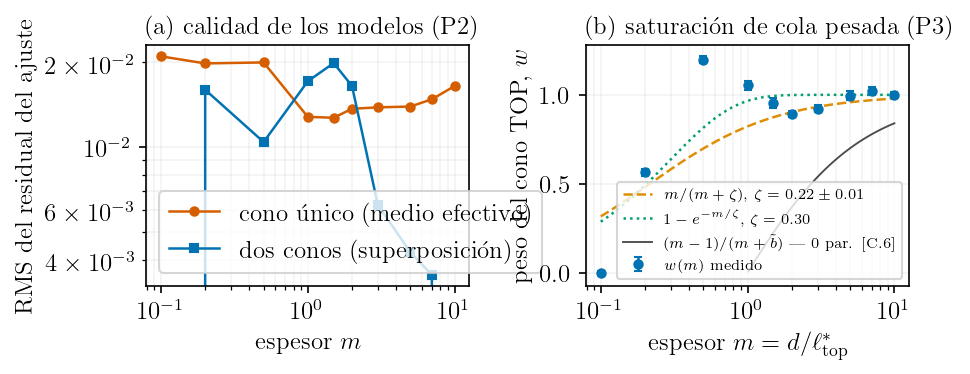

In [9]:
# ===========================================================================
# F15 -- fallo del cono unico vs exito de los dos conos; w(m) y P3
# ===========================================================================
TH_FIT = CONV["th_fit_rad"]
th_ref, E_bot = profile_mean(G_BOTLIKE)
_,      E_top = profile_mean(G_TOPLIKE)
mfit = th_ref <= TH_FIT

A_BOT = peak_height(E_bot) - 1.0     # amplitudes de los controles (para C.10)
A_TOP = peak_height(E_top) - 1.0

def fit_single_cone(theta, E):
    model = lambda th, A, L: 1.0 + A * cone_shape(k * L * th)
    p0 = [max(E.max() - 1.0, 0.1), L_BOT]
    popt, _ = curve_fit(model, theta[mfit], E[mfit], p0=p0, maxfev=20000)
    resid = E[mfit] - model(theta[mfit], *popt)
    return popt[0], popt[1], np.sqrt(np.mean(resid ** 2))

def fit_weight(E_d):
    """w cerrado por minimos cuadrados: (y - fb) = w (ft - fb)."""
    ft, fb, y = E_top - 1.0, E_bot - 1.0, E_d - 1.0
    dd = (ft - fb)[mfit]
    w = float(np.sum((y - fb)[mfit] * dd) / np.sum(dd ** 2))
    resid = (y - fb - w * (ft - fb))[mfit]
    return w, np.sqrt(np.mean(resid ** 2))

rows = []
for g in groups:
    theta, E = profile_mean(g)
    A1, Leff, rms1 = fit_single_cone(theta, E)
    w, rms2 = fit_weight(E)
    ws = [fit_weight(profile_one(key)[1])[0] for key in g.replicas_keys]
    sw = np.std(ws, ddof=1) / np.sqrt(len(ws))
    rows.append((g.mult, Leff, rms1, w, sw, rms2))
    print(f"m={g.mult:5.2f}: cono único L_eff={Leff:7.2f} um RMS={rms1:.2e}   |   "
          f"dos conos w={w:.3f}±{sw:.3f} RMS={rms2:.2e}")

mults_, Leff_, rms1_, w_, sw_, rms2_ = map(np.array, zip(*rows))

# --- P3: dos formas de saturacion + prediccion de cero parametros ----------
sig_w = np.maximum(sw_, 1e-3)
z_d, cov_d = curve_fit(w_ratio, mults_, w_, p0=[ZETA_TEO], sigma=sig_w,
                       absolute_sigma=True)
z_e, cov_e = curve_fit(w_exp,  mults_, w_, p0=[1.0], sigma=sig_w,
                       absolute_sigma=True)
ZETA_FIT, sZETA_FIT = float(z_d[0]), float(np.sqrt(cov_d[0, 0]))
chi2_d = np.sum(((w_ - w_ratio(mults_, *z_d)) / sig_w) ** 2)
chi2_e = np.sum(((w_ - w_exp(mults_,  *z_e)) / sig_w) ** 2)
ndf_w = len(mults_) - 1
print(f"\n[P3] cola pesada : zeta = {ZETA_FIT:.2f} ± {sZETA_FIT:.2f}  "
      f"(teo {ZETA_TEO:.2f})   chi2/ndf = {chi2_d:.1f}/{ndf_w}")
print(f"[P3] exponencial: zeta = {z_e[0]:.2f}                 "
      f"chi2/ndf = {chi2_e:.1f}/{ndf_w}   -> debe perder")

# --- P5 cuantitativo: m_c predicho con el zeta medido [Eq. C.10] -----------
w_c = A_BOT / (A_TOP + A_BOT)
M_C_PRED = ZETA_FIT * w_c / (1.0 - w_c)
print(f"[P5] w(m_c) = A_bot/(A_top+A_bot) = {w_c:.3f}  ->  "
      f"m_c(pred) = {M_C_PRED:.2f}   vs  m_c(obs) ~ {M_C_OBS:.2f}")

mm = np.geomspace(mults_.min(), mults_.max(), 200)
apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN))

ax1.plot(mults_, rms1_, "o-", ms=4, color=COL[3], label="cono único (medio efectivo)")
ax1.plot(mults_, rms2_, "s-", ms=4, color=COL[0], label="dos conos (superposición)")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"espesor $m$"); ax1.set_ylabel("RMS del residual del ajuste")
ax1.grid(alpha=0.15, which="both"); ax1.legend()
ax1.set_title("(a) calidad de los modelos (P2)", loc="left")

ax2.errorbar(mults_, w_, sw_, fmt="o", ms=4, capsize=2, color=COL[0], ls="none",
             label=r"$w(m)$ medido")
ax2.plot(mm, w_ratio(mm, ZETA_FIT), "--", color=COL[1],
         label=rf"$m/(m+\zeta)$, $\zeta={ZETA_FIT:.2f}\pm{sZETA_FIT:.2f}$")
ax2.plot(mm, w_exp(mm, z_e[0]), ":", color=COL[2],
         label=rf"$1-e^{{-m/\zeta}}$, $\zeta={z_e[0]:.2f}$")
mm1 = mm[mm >= 1.0]
ax2.plot(mm1, w_teo(mm1), "-", color="k", lw=0.9, alpha=0.7,
         label=r"$(m-1)/(m+\tilde b)$ — 0 par. [C.6]")
ax2.set_xscale("log")
ax2.set_xlabel(r"espesor $m = d/\ell^*_{\rm top}$")
ax2.set_ylabel(r"peso del cono TOP, $w$")
ax2.grid(alpha=0.15, which="both"); ax2.legend(fontsize=7)
ax2.set_title("(b) saturación de cola pesada (P3)", loc="left")
fig.tight_layout()
fig.savefig(FIGDIR / "F15_modelo_dos_conos.pdf")
plt.show()


## F16 — Time-resolved: $\Delta\theta(t)$ y la interfaz enterrada — **P6a**

Para un medio homogéneo, $\Delta\theta(t)\propto (Dt)^{-1/2}$ [Eq. C.11]: recta de pendiente
$-1/2$ en log-log, con $D = v\,\ell^*/3$. En el medio estratificado la luz difunde primero en
TOP ($D$ grande, cono estrecho); al alcanzar la interfaz en $t^*$ [Eq. C.12] la dinámica cruza
al BOT ($D$ menor) y la curva se **quiebra hacia arriba** respecto de la referencia TOP. Los
controles del propio barrido, con la **misma grilla temporal**, sirven de referencias sin
interpolación. Gate de calidad por bin: pico $>5\sigma$ del ruido de cola y FWHM finita.


m= 0.10: 100 bins temporales válidos
m= 0.20: 100 bins temporales válidos
m= 0.50: 100 bins temporales válidos
m= 1.00: 100 bins temporales válidos
m= 1.50: 100 bins temporales válidos
m= 2.00: 100 bins temporales válidos
m= 3.00: 100 bins temporales válidos
m= 5.00: 100 bins temporales válidos
m= 7.00: 100 bins temporales válidos
m=10.00: 100 bins temporales válidos


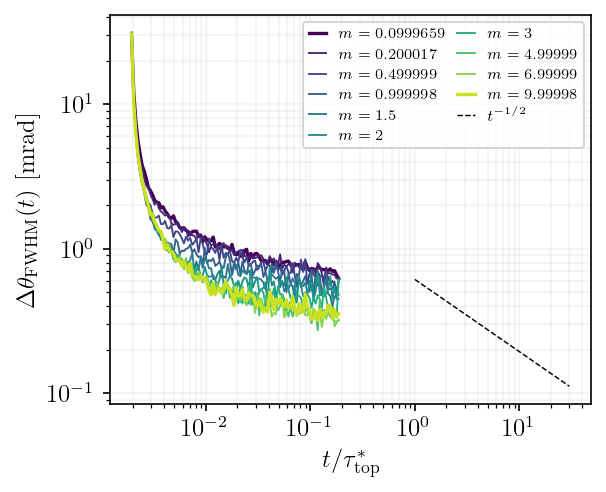

In [10]:
# ===========================================================================
# F16 -- ancho del cono vs tiempo por espesor (intensidades sumadas)
# ===========================================================================
TIME_STRIDE = 1                     # sube a 2-3 si tarda demasiado
Z_SELECT = list(range(len(groups)))

t_idx = np.arange(1, N_TIME_BINS + 1, TIME_STRIDE)
WIDTHS = {}                          # g.mult -> (t_fs validos, FWHM mrad)

for gi in Z_SELECT:
    g = groups[gi]
    ts, ws = [], []
    for it in t_idx:
        try:
            theta, E = profile_mean(g, time_index=int(it))
        except Exception:
            continue
        noise = estimate_noise(E)
        e0 = peak_height(E)
        if not np.isfinite(e0) or (e0 - 1.0) < CONV["snr_min_time"] * noise:
            continue
        fw = fwhm_theta(theta, E)
        if not np.isfinite(fw):
            continue
        ts.append(T_FS[it - 1]); ws.append(fw * 1e3)
    WIDTHS[g.mult] = (np.asarray(ts), np.asarray(ws))
    print(f"m={g.mult:5.2f}: {len(ts)} bins temporales válidos")

apply(width_frac=0.62)
fig, ax = plt.subplots(figsize=(0.62 * TEXTWIDTH_IN, 0.5 * TEXTWIDTH_IN))
for c, gi in zip(plt.cm.viridis(np.linspace(0, 0.92, len(Z_SELECT))), Z_SELECT):
    g = groups[gi]
    ts, ws = WIDTHS[g.mult]
    if len(ts) == 0:
        continue
    lw = 1.6 if g in (G_BOTLIKE, G_TOPLIKE) else 0.9
    ax.plot(ts / TAU_TOP_FS, ws, "-", color=c, lw=lw, label=rf"$m={g.mult:g}$")

# guia de pendiente -1/2 anclada en la referencia TOP (P6a)
tt = np.array([1.0, 30.0])
ts_ref, ws_ref = WIDTHS[G_TOPLIKE.mult]
if len(ts_ref):
    w_anchor = np.interp(3.0 * TAU_TOP_FS, ts_ref, ws_ref)
    ax.plot(tt, w_anchor * (tt / 3.0) ** (-0.5), "k--", lw=0.7, label=r"$t^{-1/2}$")

    # pendiente medida de la referencia (numero citable de P6a)
    mfit_t = ts_ref > 2.0 * TAU_TOP_FS
    if np.count_nonzero(mfit_t) > 5:
        sl, ic = np.polyfit(np.log(ts_ref[mfit_t]), np.log(ws_ref[mfit_t]), 1)
        print(f"[P6a] pendiente log-log de la referencia TOP: {sl:.3f}  (teo -0.5)")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$t / \tau^*_{\rm top}$")
ax.set_ylabel(r"$\Delta\theta_{\rm FWHM}(t)$ [mrad]")
ax.grid(alpha=0.15, which="both")
ax.legend(ncol=2, columnspacing=0.8, handlelength=1.2, fontsize=7)
fig.savefig(FIGDIR / "F16_ancho_vs_t.pdf")
plt.show()


## F17 — Escalamiento difusivo $t^*\propto d^2$ y plateau de contraste — **P6b**

Cociente $R_d(t) = \Delta\theta_d(t)/\Delta\theta_{\rm top}(t)$ contra la referencia TOP
[Eq. C.13] (misma grilla, cociente bin a bin). $R$ parte de 1 y sube hacia el contraste
asintótico $R_\infty = \sqrt{\ell^*_{\rm top}/\ell^*_{\rm bot}}$ [Eq. C.14] cuando los
fotones alcanzan el fondo; $t^*$ = primer cruce persistente del punto medio geométrico.
Predicciones: $t^* = \alpha\,m^2\,\tau^*_{\rm top}$ con $\alpha \approx 3/2$ [Eq. C.12]
(recta de pendiente 1 en log-log vs $m^2$), y plateau $R_{\rm tardío} \approx R_\infty$.
Solo participan los espesores con interfaz alcanzable en la ventana temporal
($\alpha\,m^2\,\tau^* < t_{\max}$).


m= 0.10: R_tardio=1.94  t* = 0.00 tau*_top
m= 0.20: R_tardio=1.86  t* = 0.00 tau*_top
m= 0.50: R_tardio=1.72  t* = 0.00 tau*_top
m= 1.00: R_tardio=1.56  t* = 0.01 tau*_top
m= 1.50: R_tardio=1.44  t* = 0.01 tau*_top
m= 2.00: R_tardio=1.36  t* = 0.01 tau*_top
m= 3.00: R_tardio=1.18  t* = 0.02 tau*_top
m= 5.00: R_tardio=0.99 -> sin quiebre resoluble
m= 7.00: R_tardio=0.94 -> sin quiebre resoluble

[P6b] plateau R_tardio (delgados) = 1.79   predicho sqrt(l*top/l*bot) = 2.26


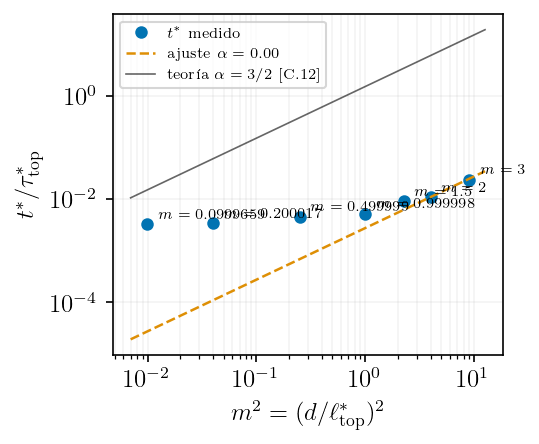


[P6b] alpha ajustado = 0.00   (teoría 3/2 = 1.50)


In [11]:
# ===========================================================================
# F17 -- t*(m) del cociente contra la referencia TOP; alpha y R_inf
# ===========================================================================
ts_ref, ws_ref = WIDTHS[G_TOPLIKE.mult]

tstars, mstars, R_lates = [], [], []
for g in groups[:-1]:                       # excluye la propia referencia
    ts, ws = WIDTHS[g.mult]
    if len(ts) < 8 or len(ts_ref) < 8:
        continue
    t_lo, t_hi = max(ts.min(), ts_ref.min()), min(ts.max(), ts_ref.max())
    msk = (ts >= t_lo) & (ts <= t_hi)
    R = ws[msk] / np.interp(ts[msk], ts_ref, ws_ref)
    tR = ts[msk]
    if len(R) < 8:
        continue
    R_late = np.median(R[-max(3, len(R)//5):])
    if R_late < 1.15:
        print(f"m={g.mult:5.2f}: R_tardio={R_late:.2f} -> sin quiebre resoluble")
        continue
    thr = np.sqrt(R_late)                    # punto medio geometrico entre 1 y R_late
    above = (R > thr) & (np.roll(R, -1) > thr)   # cruce persistente (2 bins)
    idx = np.where(above)[0]
    if len(idx) == 0:
        continue
    tstars.append(tR[idx[0]] / TAU_TOP_FS)
    mstars.append(g.mult)
    R_lates.append(R_late)
    print(f"m={g.mult:5.2f}: R_tardio={R_late:.2f}  t* = {tstars[-1]:.2f} tau*_top")

tstars, mstars, R_lates = map(np.asarray, (tstars, mstars, R_lates))

# --- P6b plateau: los espesores delgados deben saturar en R_inf ------------
if len(R_lates):
    # el plateau limpio es el de los espesores mas delgados (fondo dominante a t tardio)
    R_INF_OBS = float(np.median(R_lates[mstars <= np.median(mstars)])) \
                if len(R_lates) > 2 else float(np.median(R_lates))
    print(f"\n[P6b] plateau R_tardio (delgados) = {R_INF_OBS:.2f}   "
          f"predicho sqrt(l*top/l*bot) = {R_INF_PRED:.2f}")

apply(width_frac=0.55)
fig, ax = plt.subplots(figsize=(0.55 * TEXTWIDTH_IN, 0.45 * TEXTWIDTH_IN))
ALPHA_FIT = np.nan
if len(tstars) >= 2:
    u = mstars ** 2
    ALPHA_FIT = float(np.sum(u * tstars) / np.sum(u ** 2))   # recta por el origen
    uu = np.geomspace(u.min() * 0.7, u.max() * 1.4, 50)
    ax.plot(u, tstars, "o", ms=5, color=COL[0], label=r"$t^*$ medido")
    ax.plot(uu, ALPHA_FIT * uu, "--", color=COL[1],
            label=rf"ajuste $\alpha={ALPHA_FIT:.2f}$")
    ax.plot(uu, ALPHA_TEO * uu, "-", color="k", lw=0.8, alpha=0.6,
            label=rf"teoría $\alpha=3/2$ [C.12]")
    for mi, ui, ti in zip(mstars, u, tstars):
        ax.annotate(rf"$m={mi:g}$", (ui, ti), textcoords="offset points",
                    xytext=(5, 3), fontsize=7)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$m^2 = (d/\ell^*_{\rm top})^2$")
    ax.set_ylabel(r"$t^* / \tau^*_{\rm top}$")
    ax.grid(alpha=0.15, which="both"); ax.legend(fontsize=7)
    fig.savefig(FIGDIR / "F17_tstar_vs_d2.pdf")
    plt.show()
    print(f"\n[P6b] alpha ajustado = {ALPHA_FIT:.2f}   (teoría 3/2 = {ALPHA_TEO:.2f})")
else:
    print("insuficientes t* para el ajuste: revisa el gate de calidad de F16")


## F18 — Inversión del espesor — **P7**

Cierre del capítulo: recuperar $\hat d$ desde el cono por las **dos rutas independientes**
de §C.7 y confrontarlas con el $d$ verdadero de la simulación.

- **Ruta estacionaria** $\hat m_w$: se invierte el peso medido, $\hat m = \zeta\,w/(1-w)$
  [Eq. C.7], con $\zeta$ calibrado **leave-one-out** (para cada espesor, $\zeta$ se ajusta
  con los demás puntos del barrido — sin circularidad). El error se propaga desde $\pm s_w$.
- **Ruta temporal** $\hat m_t$: desde el tiempo de quiebre con la constante **teórica**,
  $\hat m = \sqrt{t^*/(\alpha_{\rm teo}\,\tau^*_{\rm top})}$ [Eq. C.12] — independiente de
  la calibración estacionaria (usar el $\alpha$ ajustado en F17 sería circular).

El acuerdo de ambas rutas entre sí y con la diagonal es la demostración de que el CBS
funciona como sonda métrica del espesor, y sus desviaciones delimitan las ventanas de
sensibilidad de cada ruta (§C.7: $w$ pierde sensibilidad en los extremos $w\to0,1$;
$t^*$ requiere interfaz alcanzable en la ventana temporal).


zeta leave-one-out: [0.231 0.332 0.227 0.218 0.215 0.215 0.216 0.216]


/var/folders/hl/qm9fczw178qg19fkz2_x7sqr0000gn/T/ipykernel_64822/648512307.py:56: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


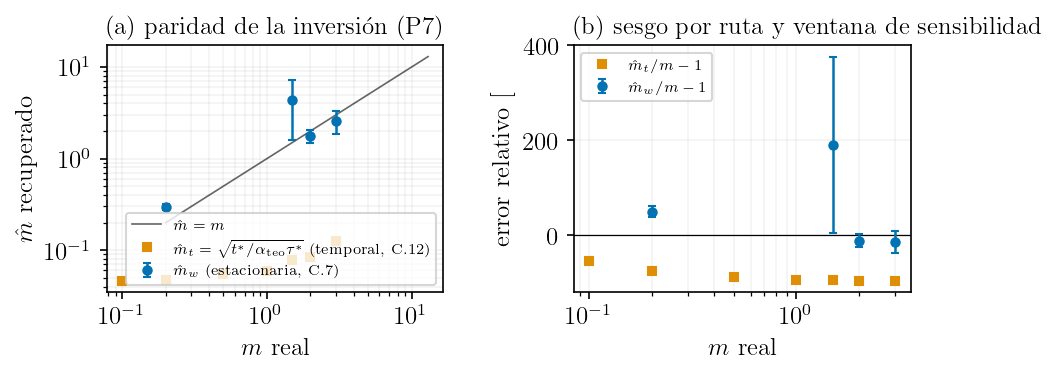

[P7] estacionaria: mediana |m_hat/m - 1| = 32.0 %  (4 espesores)
[P7] temporal    : mediana |m_hat/m - 1| = 94.1 %  (7 espesores)


In [12]:
# ===========================================================================
# F18 -- inversion: m_hat estacionario (leave-one-out) y temporal vs m real
# ===========================================================================
interior = np.arange(1, len(mults_) - 1)     # excluye los controles del barrido

# --- ruta estacionaria: zeta leave-one-out, luego m_hat = zeta w/(1-w) -----
m_hat_w, s_m_hat_w, zetas_loo = [], [], []
for i in interior:
    msk = np.ones(len(mults_), bool); msk[i] = False
    zi, _ = curve_fit(w_ratio, mults_[msk], w_[msk], p0=[ZETA_TEO],
                      sigma=np.maximum(sw_[msk], 1e-3), absolute_sigma=True)
    zi = float(zi[0])
    wi, swi = w_[i], max(sw_[i], 1e-3)
    if not (0.02 < wi < 0.98):
        m_hat_w.append(np.nan); s_m_hat_w.append(np.nan); zetas_loo.append(zi)
        continue
    m_hat_w.append(zi * wi / (1.0 - wi))
    s_m_hat_w.append(zi * swi / (1.0 - wi) ** 2)       # propagacion de s_w
    zetas_loo.append(zi)
m_hat_w, s_m_hat_w = np.asarray(m_hat_w), np.asarray(s_m_hat_w)
print("zeta leave-one-out:", np.round(zetas_loo, 3))

# --- ruta temporal: m_hat = sqrt(t*/alpha_teo), alpha teorico (no ajustado) -
m_hat_t = np.sqrt(tstars / ALPHA_TEO) if len(tstars) else np.array([])

# --- figura: paridad + error relativo --------------------------------------
apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN))

mv = mults_[interior]
dd = np.geomspace(min(mv.min(), 0.3), mults_.max() * 1.3, 50)
ax1.plot(dd, dd, "k-", lw=0.8, alpha=0.6, label=r"$\hat m = m$")
ax1.errorbar(mv, m_hat_w, s_m_hat_w, fmt="o", ms=4, capsize=2, color=COL[0],
             ls="none", label=r"$\hat m_w$ (estacionaria, C.7)")
if len(m_hat_t):
    ax1.plot(mstars, m_hat_t, "s", ms=4, color=COL[1],
             label=r"$\hat m_t=\sqrt{t^*/\alpha_{\rm teo}\tau^*}$ (temporal, C.12)")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$m$ real"); ax1.set_ylabel(r"$\hat m$ recuperado")
ax1.grid(alpha=0.15, which="both"); ax1.legend(fontsize=7)
ax1.set_title("(a) paridad de la inversión (P7)", loc="left")

ok_w = np.isfinite(m_hat_w)
ax2.axhline(0, c="k", lw=0.6)
ax2.errorbar(mv[ok_w], 100 * (m_hat_w[ok_w] / mv[ok_w] - 1),
             100 * s_m_hat_w[ok_w] / mv[ok_w],
             fmt="o", ms=4, capsize=2, color=COL[0], ls="none",
             label=r"$\hat m_w/m - 1$")
if len(m_hat_t):
    ax2.plot(mstars, 100 * (m_hat_t / mstars - 1), "s", ms=4, color=COL[1],
             label=r"$\hat m_t/m - 1$")
ax2.set_xscale("log")
ax2.set_xlabel(r"$m$ real"); ax2.set_ylabel(r"error relativo [%]")
ax2.grid(alpha=0.15, which="both"); ax2.legend(fontsize=7)
ax2.set_title("(b) sesgo por ruta y ventana de sensibilidad", loc="left")
fig.tight_layout()
fig.savefig(FIGDIR / "F18_inversion_espesor.pdf")
plt.show()

# --- numeros citables de P7 ------------------------------------------------
if ok_w.any():
    err_w = np.abs(m_hat_w[ok_w] / mv[ok_w] - 1)
    print(f"[P7] estacionaria: mediana |m_hat/m - 1| = {100*np.median(err_w):.1f} %  "
          f"({ok_w.sum()} espesores)")
if len(m_hat_t):
    err_t = np.abs(m_hat_t / mstars - 1)
    print(f"[P7] temporal    : mediana |m_hat/m - 1| = {100*np.median(err_t):.1f} %  "
          f"({len(m_hat_t)} espesores)")


## Tabla resumen y números citables

$(z,\ m,\ \theta_{\rm FWHM},\ E_0,\ \rho,\ L_{\rm eff},\ w,\ t^*,\ \hat m_w,\ \hat m_t)$
→ CSV + filas LaTeX, seguido del bloque de números citables (uno por predicción), listo
para el texto de §5.4.


In [13]:
# ===========================================================================
# Tabla resumen -> CSV + LaTeX
# ===========================================================================
tst_map = dict(zip(mstars, tstars)) if len(tstars) else {}
mhw_map = dict(zip(mults_[interior], m_hat_w))
mht_map = dict(zip(mstars, m_hat_t)) if len(m_hat_t) else {}

rows_t = []
for i, g in enumerate(groups):
    rows_t.append({
        "z_um": g.z, "mult": g.mult,
        "FWHM_mrad": FW[i], "s_FWHM": sFW[i],
        "E0": E0[i], "s_E0": sE0[i],
        "rho": RHO[i], "s_rho": sRHO[i],
        "L_eff_um": Leff_[i], "w_top": w_[i], "s_w": sw_[i],
        "tstar_taustar": tst_map.get(g.mult, np.nan),
        "m_hat_w": mhw_map.get(g.mult, np.nan),
        "m_hat_t": mht_map.get(g.mult, np.nan),
    })
df_cap = pd.DataFrame(rows_t)
df_cap.to_csv(FIGDIR / "tabla_capas.csv", index=False)
display(df_cap.round(4))

def pm(v, s, nd=3):
    return rf"${v:.{nd}f} \pm {s:.{nd}f}$"

def num_or_dash(v, nd=2):
    return f"{v:.{nd}f}" if np.isfinite(v) else "--"

lines = []
for _, r in df_cap.iterrows():
    lines.append("    " + " & ".join([
        f"{r['mult']:g}", f"{r['z_um']:.0f}",
        pm(r["FWHM_mrad"], r["s_FWHM"], 3),
        pm(r["E0"], r["s_E0"]),
        pm(r["w_top"], r["s_w"]),
        num_or_dash(r["tstar_taustar"]),
        num_or_dash(r["m_hat_w"]),
        num_or_dash(r["m_hat_t"]),
    ]) + r" \\")
tex = "\n".join(lines)
(FIGDIR / "tabla_capas.tex").write_text(tex)
print(tex)
print(f"\nguardado: {FIGDIR/'tabla_capas.csv'} y {FIGDIR/'tabla_capas.tex'}")


,z_um,mult,FWHM_mrad,s_FWHM,E0,s_E0,rho,s_rho,L_eff_um,w_top,s_w,tstar_taustar,m_hat_w,m_hat_t
0,11.79,0.1,2.0398,0.0170,1.7269,0.0014,0.2731,0.0014,18.1497,0.0000,0.0124,0.0032,NaN,0.0465
1,23.59,0.2,2.0200,0.0170,1.6586,0.0015,0.3414,0.0015,17.9402,0.5642,0.0189,0.0034,0.2985,0.0476
2,58.97,0.5,2.6709,0.0299,1.5689,0.0020,0.4311,0.0020,11.9810,1.1985,0.0179,0.0045,NaN,0.0547
3,117.94,1.0,3.0436,0.0821,1.5784,0.0014,0.4216,0.0014,11.7227,1.0525,0.0260,0.0051,NaN,0.0586
4,176.91,1.5,3.0274,0.0470,1.5909,0.0026,0.4091,0.0026,11.8406,0.9524,0.0289,0.0089,4.3642,0.0772
5,235.88,2.0,2.8634,0.0313,1.6014,0.0012,0.3986,0.0012,12.4222,0.8916,0.0153,0.0107,1.7675,0.0846
6,353.82,3.0,2.6335,0.0461,1.6084,0.0022,0.3916,0.0022,13.5592,0.9223,0.0199,0.0235,2.5576,0.1252
7,589.70,5.0,2.4122,0.0122,1.6133,0.0018,0.3867,0.0018,14.2272,0.9949,0.0258,NaN,NaN,NaN
8,825.58,7.0,2.4532,0.0369,1.6133,0.0021,0.3867,0.0021,14.0318,1.0191,0.0223,NaN,NaN,NaN
9,1179.40,10.0,2.3866,0.0254,1.6162,0.0013,0.3838,0.0013,13.8104,1.0000,0.0146,NaN,NaN,NaN


    0.0999659 & 12 & $2.040 \pm 0.017$ & $1.727 \pm 0.001$ & $0.000 \pm 0.012$ & 0.00 & -- & 0.05 \\
    0.200017 & 24 & $2.020 \pm 0.017$ & $1.659 \pm 0.002$ & $0.564 \pm 0.019$ & 0.00 & 0.30 & 0.05 \\
    0.499999 & 59 & $2.671 \pm 0.030$ & $1.569 \pm 0.002$ & $1.199 \pm 0.018$ & 0.00 & -- & 0.05 \\
    0.999998 & 118 & $3.044 \pm 0.082$ & $1.578 \pm 0.001$ & $1.052 \pm 0.026$ & 0.01 & -- & 0.06 \\
    1.5 & 177 & $3.027 \pm 0.047$ & $1.591 \pm 0.003$ & $0.952 \pm 0.029$ & 0.01 & 4.36 & 0.08 \\
    2 & 236 & $2.863 \pm 0.031$ & $1.601 \pm 0.001$ & $0.892 \pm 0.015$ & 0.01 & 1.77 & 0.08 \\
    3 & 354 & $2.634 \pm 0.046$ & $1.608 \pm 0.002$ & $0.922 \pm 0.020$ & 0.02 & 2.56 & 0.13 \\
    4.99999 & 590 & $2.412 \pm 0.012$ & $1.613 \pm 0.002$ & $0.995 \pm 0.026$ & -- & -- & -- \\
    6.99999 & 826 & $2.453 \pm 0.037$ & $1.613 \pm 0.002$ & $1.019 \pm 0.022$ & -- & -- & -- \\
    9.99998 & 1179 & $2.387 \pm 0.025$ & $1.616 \pm 0.001$ & $1.000 \pm 0.015$ & -- & -- & -- \\

guardado: figs_t

In [14]:
# ===========================================================================
# Numeros citables (uno por prediccion) -- para el texto de 5.4
# ===========================================================================
print("=" * 70)
print("NUMEROS CITABLES 5.4")
print("=" * 70)
for sub, (chi2, rms) in GATE_STATS.items():
    print(f"P1  gate vs {sub:14s}: chi2/bin = {chi2:.2f}   RMS = {rms:.2e}")
print(f"P2  RMS cono unico / dos conos (mediana interior): "
      f"{np.median(rms1_[interior] / rms2_[interior]):.1f}x")
print(f"P3  zeta = {ZETA_FIT:.2f} ± {sZETA_FIT:.2f}   (teo {ZETA_TEO:.2f});   "
      f"chi2 cola pesada / exponencial = {chi2_d:.1f} / {chi2_e:.1f}")
if _rho_ok:
    print(f"P4  m_rho = {M_RHO_FIT:.3f} ± {sM_RHO_FIT:.3f}   (teo (1-g_top)/2 = {M_RHO_PRED:.3f})")
print(f"P5  m_c obs ~ {M_C_OBS:.2f}   (pred zeta*w_c/(1-w_c) = {M_C_PRED:.2f})")
if np.isfinite(ALPHA_FIT):
    print(f"P6  alpha = {ALPHA_FIT:.2f}   (teo 1.50);   "
          f"R_inf obs = {R_INF_OBS:.2f}   (teo {R_INF_PRED:.2f})")
if ok_w.any():
    print(f"P7  mediana |m_hat_w/m - 1| = {100*np.median(err_w):.1f} %"
          + (f";   |m_hat_t/m - 1| = {100*np.median(err_t):.1f} %" if len(m_hat_t) else ""))
print("=" * 70)


NUMEROS CITABLES 5.4
P1  gate vs radius_0.075  : chi2/bin = 9798.53   RMS = 2.64e-01
P1  gate vs radius_0.035  : chi2/bin = 46.66   RMS = 2.48e-02
P2  RMS cono unico / dos conos (mediana interior): 1.6x
P3  zeta = 0.22 ± 0.01   (teo 1.71);   chi2 cola pesada / exponencial = 1542.6 / 1083.6
P4  m_rho = 0.112 ± 0.004   (teo (1-g_top)/2 = nan)
P5  m_c obs ~ nan   (pred zeta*w_c/(1-w_c) = 0.25)
P6  alpha = 0.00   (teo 1.50);   R_inf obs = 1.79   (teo 2.26)
P7  mediana |m_hat_w/m - 1| = 32.0 %;   |m_hat_t/m - 1| = 94.1 %
